# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [ ]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1

dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

# Hier wordt het zware deeltje (de pol) toegevoegd aan de lijst met verder alleen maar lichte deeltjes (de watermoleculen)
particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 

```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
```

```{solution} ex-brownian-1
In de laatste regel van het bovenstaande script word het zwaren deeltje, de pol, toegevoegd aan de deeltjes array die verder lichte deeltjes, de water moleculen, bevat.
```

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



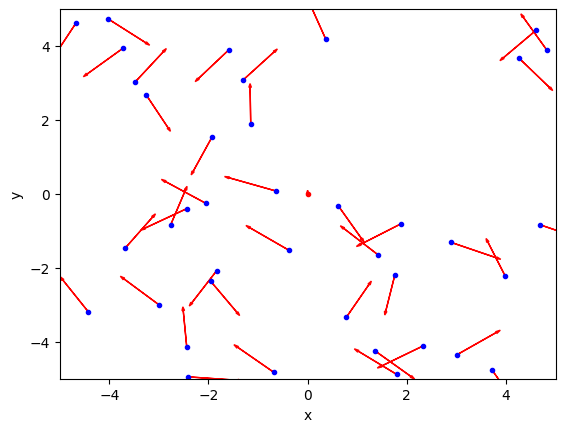

In [4]:
# Inspecteren van beginsituatie
plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)


for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
               particle_object.v[0],particle_object.v[1], 
               head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
Deze code geeft ieder deeltje zijn bijbehorende snelheidsvector. De lengegte heirvan is altijd gelijk, vanwege de volgende line: vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2). Hier wordt random een + of - y richting gekozen en dan wordt op basis van de vx en v_0, met behulp van de stelling van pitagoras vy bepaald, zodat $vy^2 + vx^2 = v_0^2$.
```

We gaan nu de functies van de simulatie weer aanroepen:

In [5]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r

def handle_collisions(particles, counter):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                counter += 1 #counter +1 doen, omdat er een botsing plaatsvind
                particle_collision(particles[i], particles[j])
    return counter
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

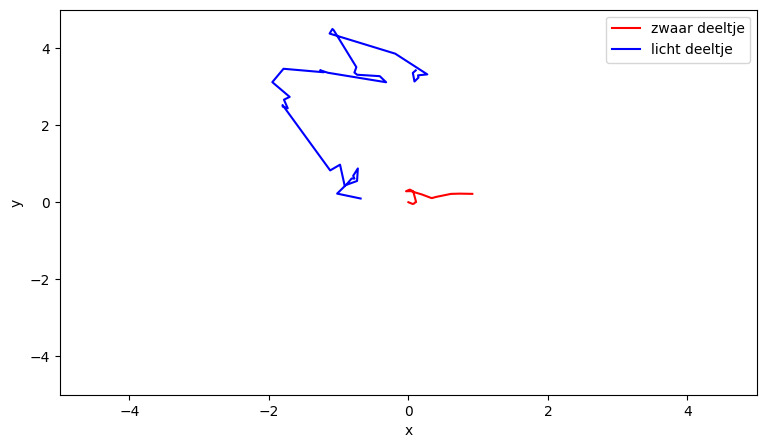

In [6]:
# tracken van het zware deeltje en een licht deeltje
track_x_z = []
track_y_z = []
track_x_l = []
track_y_l = []

counter = 0 #counter op 0 stellen
t_max = 16 #s
n_iter = int(t_max/dt) #aantal tijdsstappen berekenen
counter_array = np.zeros(n_iter) #array van nullen aanmaken met evenveel elementen als er tijdstappen zijn
#your code/answer

#your code/answer

#your code/answer

for i in range(n_iter):
#your code/answer
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    counter = handle_collisions(particles, counter)
    counter_array[i] = counter

#your code/answer
    #positie data van het zwaren en het lichte deeltje toevoegen aan de bijbehorende array's
    track_x_z.append(particles[N-1].r[0])
    track_y_z.append(particles[N-1].r[1])
    track_x_l.append(particles[0].r[0])
    track_y_l.append(particles[0].r[1])
    
#your code/answer

#de track van het zware en hetlichte deeltje plotten
plt.figure(figsize=(9,5))
plt.plot(track_x_z,track_y_z,'r',label='zwaar deeltje')
plt.plot(track_x_l,track_y_l,'b',label='licht deeltje')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)
plt.legend()
#your code/answer
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
#your code/answer
Zowel de baan van het zware als het lichte deeltje hebben een erg sporadische baan. Al valt wel op dat het lichte deeltje veel meer afstand aflecht en veel scherpere bewegingsveranderingen maakt. 
Iedere keer dat je de simulatie runt komt er iets heel anders uit, voor zowel het zware als het lichte deeltje. Al blijft het verschil tussen het zware en het lichte deeltje duidenlijk.
```

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

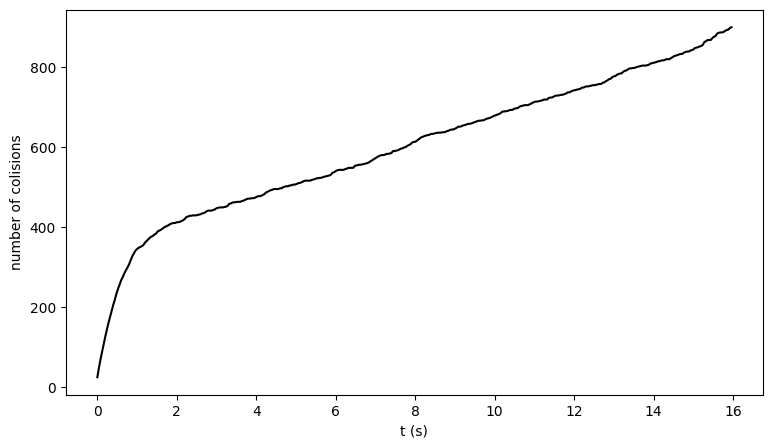

In [7]:
#your code/answer
t_array = np.arange(0,t_max,dt) #t_array aanmaken van alle tijdstappen

#aantal colisions geplot over de tijd
plt.figure(figsize=(9,5))
plt.plot(t_array,counter_array,'k')
plt.xlabel('t (s)')
plt.ylabel('number of colisions')
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


In [8]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c, pl):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c
        self.pl = pl #afgelegde pad lengte

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
    

In [9]:
#your code/answer
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10*361/41 #juiste box grote schaling uitrekenen: oude grote * nieuw aantal deeltjes / oud aantal deeltjes
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
particles = []
N = 360
v_0 = 1
dt = 0.04

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue',pl = 0)) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red', pl = 0)) #hier wordt het zware deeltje (de pol) toegevoegd aan de lijst met verder alleen maar lichte deeltjes (de watermoleculen)



In [10]:

def handle_collisions(particles):
#your code/answer
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                particle_collision(particles[i], particles[j])
#your code/answer


In [11]:

path_length = 0
t_max = 16 #s
n_iter = int(t_max/dt) #aantal tijdsstappen berekenen
counter_array = np.zeros(n_iter) #array van nullen aanmaken met evenveel elementen als er tijdstappen zijn

for i in range(n_iter):
#your code/answer
    
    for p in particles:
        p.update_position()     # Update positie        
        p.boxcollision()        # Wandbotsing werkt per deeltje
        p.pl += np.sqrt(np.dot(p.v,p.v)*dt) #pad lengte in deze tijdstap uitrekenen en die optellen bij de al afgelegde pad lengte
        
    handle_collisions(particles)

#your code/answer


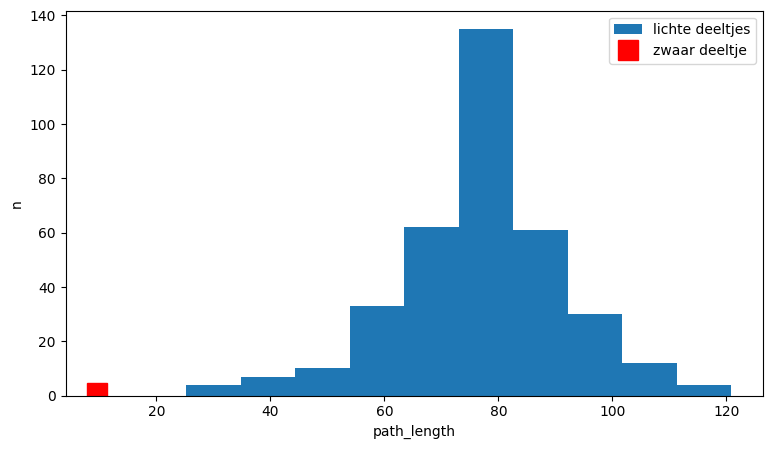

In [12]:
pl_array = np.array([p.pl for p in particles]) #array aanmaken van de afgelegde pad lengtes van alle deeltjes

#histogram van de afgelegde pad lengte plotten
plt.figure(figsize=(9,5))
plt.hist(pl_array[0:-2],10,label='lichte deeltjes') #histogram van de lichte deeljes
plt.plot(pl_array[-1],1,'rs',markersize=15,label='zwaar deeltje') #de padlengte van het zware deeltje plotten met een vierkante marker
plt.xlabel('path_length')
plt.ylabel('n')
plt.legend()
plt.show()

En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

In [13]:
#your code/answer
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self,a):
        self.v += 0.5 * a * dt #eerst de snelheid aanpassen met de helft van de acceleratie, om de dempening van de numirike intergratie te verminderen
        self.r += self.v * dt + 1/2 * a * dt**2  
        self.v += 0.5 * a * dt #nog een keer de snelheid aanpassen met de helft van de acceleratie, zodat de snelheid met de volle acceleratie is aangepast
        
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_with: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_with - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_height: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_height - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)
    
    

In [ ]:
#your code/answer
# Aanmaken van de randvoorwaarden en initiele condities
Box_height_0 = 100/2        #totale box height is 100, delen door 2, omdat vanuit het midden de uitweiking de helft van de totale hoogte is
Box_with_0 = Box_height_0/2 #box with de helft van de box height maken
Box_with = Box_with_0       # De grootte van de box kan wijzigen!
Box_height = Box_height_0

# Particles
particles = []
N = 722 #2x zoveel deltjses als de vorige simulatie
v_0 = 1
dt = 0.01
g = 98.1 #10 keer de normale zwaartekracht

#Eerste set deeltjes aanmaken, met een massa van 1 in het blauw
for i in range(int((N)/2)):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    posy = Box_height_0*np.random.uniform(-1,1)
    posx = Box_with_0*np.random.uniform(-1,1)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = [posx,posy], R=.5,c='blue')) 
    
#Tweede set deeltjes aanmaken, met een massa van 10 in het rood
for i in range(int((N)/2),N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    posy = Box_height_0*np.random.uniform(-1,1)
    posx = Box_with_0*np.random.uniform(-1,1)
    particles.append(ParticleClass(m=10.0, v=[vx, vy], r = [posx,posy], R=.5,c='green')) 



In [15]:
t_max = 3 #s
n_iter = int(t_max/dt)              #aantal tijdsstappen berekenen
counter_array = np.zeros(n_iter)    #array van nullen aanmaken met evenveel elementen als er tijdstappen zijn
a_array = np.array([0,-g])          #acceleratie array aanmaken met in de y richting de negatieve waarde van g

for i in range(n_iter):
#your code/answer
    
    for p in particles:
        p.update_position(a_array)     # Update positie        
        p.boxcollision()               # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

#your code/answer


In [16]:
from matplotlib.lines import Line2D #line2D imorteren voor de legenda

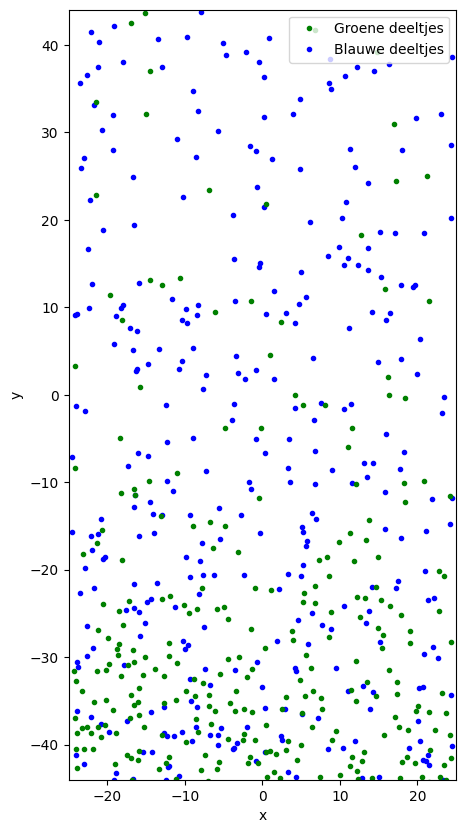

In [17]:
#eindposities van de deeltjes plotten
plt.figure(figsize=(5,10))
for particle, particle_object in enumerate(particles): #loopen door alle deeltjes
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.') #het deeltje plotten in de bijbehorende kleur
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-Box_with_0,Box_with_0)
plt.ylim(-Box_length_0,Box_length_0)
legend_elements = [
    Line2D([0], [0], marker='.', color='green', linestyle='None',
           label='Groene deeltjes'),
    Line2D([0], [0], marker='.', color='blue', linestyle='None',
           label='Blauwe deeltjes')]    # 2 dummie elementen aanmaken met dezelfde marker en kleur als de deeltjes en het bijbehorende label
plt.legend(handles=legend_elements)     # de legenda toevoegen voor de twee dummie elementen
plt.show()